# Example 8: Distributed ISL ODTS with a Rotating Lunar Surface Station

This tutorial studies **distributed** onboard orbit determination and time synchronization (ODTS) for a lunar relay constellation, and contrasts it with a **centralized** ground-based filter. The simulated constellation is NASA's five-satellite LCRNS Reference Constellation 3.1 in Elliptical Lunar Frozen Orbits (ELFOs).

Every satellite runs its **own** Schmidt EKF in parallel (five filters). Each estimates its own 8-state `[position, velocity, clock bias, clock drift]` and carries the other four satellites as *consider* states — propagated and used in the measurement update, but never directly corrected.

The measurement architecture has two link types:

- **Satellite ↔ Satellite: a dedicated two-way link.** It provides two-way **range** and **range-rate** (Doppler) — nearly clock-free, so it constrains relative geometry — plus two-way **time transfer** (the clock-bias difference `C·(b_i − b_j)`) and two-way **frequency transfer** (the clock-drift difference `C·(d_i − d_j)`). The transfers make the constellation's *relative* clocks and drifts observable across the crosslink mesh (Section 9).
- **Surface station ↔ Satellite: a one-way pseudorange each way (beacon-like).** A small network of ground stations, each a beacon, exchanges a one-way pseudorange — and its Doppler — with every satellite above its elevation mask. The satellite-side measurements give the onboard filters the one *absolute* time reference the clock-free crosslinks lack; the station-side measurements feed a **centralized ground filter** that estimates the whole constellation from ground tracking alone (Section 10).

The five distributed filters are also **coupled**: every 10 minutes each satellite broadcasts its posterior self-estimate (mean **and** covariance), and every other filter fuses it into the matching consider block. Sections 7–8 show why the naive fusion is over-optimistic and fix it with Covariance Intersection.

The estimators live in `lupnt::IslOdtsApp`; the `lupnt::IslOdtsCoordinatorApp` (on a thin `IslOdtsManager` agent) generates the truth trajectories, the station beacon schedule, and the staged measurements, orchestrates the periodic state exchange, and runs the centralized ground filter.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

import os, sys
from pathlib import Path

# Use THIS repo's pylupnt/data, not a stale copy on a global PYTHONPATH (~/.zshrc) or kernelspec.
for _b in [Path.cwd(), *Path.cwd().parents]:
    if (_b / "python/pylupnt/__init__.py").exists():
        sys.path.insert(0, str((_b / "python").resolve()))
        if (_b / "data/LuPNT_data/ephemeris").is_dir():
            os.environ["LUPNT_DATA_PATH"] = str((_b / "data/LuPNT_data").resolve())
        break
import pylupnt as pnt

np.random.seed(0)

# Host heavy interactive figures on lupnt-doc-assets instead of embedding them.
import sys as _sys
from pathlib import Path as _Path

for _p in [_Path.cwd(), *_Path.cwd().parents]:
    if (_p / "python" / "examples" / "_doc_assets.py").exists():
        _sys.path.insert(0, str(_p / "python" / "examples"))
        break
from _doc_assets import embed_plotly, embed_cesium_scene

[00.01][PyLuPNT] Initializing


## 1. LCRNS Reference Constellation -- all five satellites

The LCRNS reference document provides five ELFO satellite states at the reference
epoch **2027-03-01 00:00:00.000 UTC**, in the Moon-centered ICRF (Table 2 of the
reference). `SV-1` and `SV-2` share one orbit plane (~180&deg; apart in true anomaly);
`SV-3` and `SV-4` share a second plane; `SV-5` occupies a third. We use these Cartesian
states directly (so no Keplerian-element/frame-convention assumptions are needed) as
the truth trajectories for all five satellites. The constellation is **fully
cross-linked** -- every satellite ranges to every other -- and each runs its own onboard
filter. The orbit period is approximately 30 hours for all five.

In [2]:
t0_str = "2027-03-01T00:00:00"  # UTC, LCRNS Reference Constellation 3.1 epoch

# NASA LCRNS Reference Constellation 3.1 (Ryden & Volle, NASA GSFC), Table 2:
# Cartesian initial states in the Moon-centered ICRF, [km], [km/s].
lcrns_states_km = {
    "SV-1": ([-198.931445, 386.023132, 3458.355412], [-1.539867, 0.022243, -0.091059]),
    "SV-2": (
        [1089.980598, -2260.918271, -18984.562823],
        [0.280301, -0.004049, 0.016575],
    ),
    "SV-3": ([9187.665852, -260.470721, -8543.222759], [0.273629, 0.417588, -0.313828]),
    "SV-4": (
        [6484.019002, 14329.883921, -7966.345594],
        [-0.258433, 0.033951, 0.235264],
    ),
    "SV-5": (
        [-5074.242314, 14473.022751, -8638.530033],
        [-0.229931, -0.026926, -0.264381],
    ),
}

# LCRNS clock offsets are not specified in the reference document; assign small,
# distinct representative offsets so the crosslinks are not perfectly clock-synced.
clock_bias_s = {"SV-1": 0.0, "SV-2": 10e-6, "SV-3": -6e-6, "SV-4": 4e-6, "SV-5": -8e-6}
clock_drift_sps = {
    "SV-1": 0.0,
    "SV-2": 1e-10,
    "SV-3": -8e-11,
    "SV-4": 5e-11,
    "SV-5": -3e-11,
}

satellites = []
for name, (r_km, v_kmps) in lcrns_states_km.items():
    sat = pnt.IslOdtsSatelliteConfig()
    sat.name = name
    sat.r0_m = np.array(r_km) * 1e3
    sat.v0_mps = np.array(v_kmps) * 1e3
    sat.clock_bias_s = clock_bias_s[name]
    sat.clock_drift_sps = clock_drift_sps[name]
    satellites.append(sat)

a_m = 11316.94e3  # SMA from Table 1 (SV-1), used only to report the orbit period
period_h = 2 * np.pi * np.sqrt(a_m**3 / pnt.GM_MOON) / 3600.0
for sat in satellites:
    print(f"{sat.name}: |r0| = {np.linalg.norm(sat.r0_m) / 1e3:8.1f} km")
n_links_per_sat = len(satellites) - 1
print(
    f"ELFO period ~ {period_h:.1f} h; {len(satellites)} satellites, "
    f"{n_links_per_sat} crosslinks each, {len(satellites)} parallel filters"
)

SV-1: |r0| =   3485.5 km
SV-2: |r0| =  19149.8 km
SV-3: |r0| =  12548.6 km
SV-4: |r0| =  17631.0 km
SV-5: |r0| =  17602.3 km
ELFO period ~ 30.0 h; 5 satellites, 4 crosslinks each, 5 parallel filters


## 2. Distributed ODTS Configuration

The **truth** trajectories are propagated with a higher-fidelity lunar gravity field
(plus Earth/Sun third-body and relativistic corrections); each satellite's onboard
**filter** propagates its own state and every consider (neighbor) state with a
reduced-order gravity field, mirroring a realistic onboard force model.

The single `IslOdtsConfig` drives both halves of the split. The
`moon_gravity_*_truth`, `link_budget` and `surface_station` fields parametrize the
simulation's truth/measurement generation, while `moon_gravity_*_filter`, the
`*_sigma_*` tunings, and `consider_exchange_interval_s` configure the onboard filters.

Note the tuning of the two prior uncertainties: each satellite knows its **own**
just-initialized state to ~200 m (`initial_position_sigma_m`), but has only a **coarse
broadcast ephemeris** of its neighbors, ~500 m (`consider_position_sigma_m`). That gap
is exactly what the 10-minute inter-agent state exchange closes: as the parallel filters
converge, each neighbor's shared self-estimate becomes a far better prior than the
static broadcast.

In [3]:
cfg = pnt.IslOdtsConfig()
cfg.seed = 42
cfg.start_epoch_utc = t0_str
cfg.duration_s = 6.0 * 3600.0  # [s]
cfg.dt_s = 60.0  # [s] measurement interval
cfg.integration_step_s = 60.0  # [s]

cfg.satellites = satellites  # fully cross-linked; each runs its own filter

# Truth force model
cfg.moon_gravity_degree_truth = 16
cfg.moon_gravity_order_truth = 16
cfg.include_earth = True
cfg.include_sun = True
cfg.use_relativity = True

# Onboard filter force model (reduced-order; STM via autodiff)
cfg.moon_gravity_degree_filter = 8
cfg.moon_gravity_order_filter = 8

# --- Measurement suite --------------------------------------------------------------
# Satellite <-> Satellite: a dedicated two-way link providing (a) two-way RANGE and
# range-rate (Doppler) -- nearly clock-free, constrains relative geometry -- plus
# (b) two-way TIME transfer (clock-bias difference C*(b_i - b_j)) and (c) two-way
# FREQUENCY transfer (clock-drift difference C*(d_i - d_j)), which together make the
# constellation's relative clocks and drifts observable over the crosslink mesh.
cfg.range_sigma_m = 1.0  # [m]
cfg.range_rate_sigma_mps = 1.0e-3  # [m/s]
cfg.enable_two_way_time_transfer = True
cfg.time_transfer_sigma_m = 1.0  # [m], comparable to the ranging noise
cfg.enable_two_way_frequency_transfer = True
cfg.frequency_transfer_sigma_mps = 1.0e-3  # [m/s], comparable to the range-rate noise

# Each filter's own (estimated) state initial uncertainty
cfg.initial_position_sigma_m = 200.0
cfg.initial_velocity_sigma_mps = 0.1
cfg.initial_clock_bias_sigma_s = 1.0e-6
cfg.initial_clock_drift_sigma_sps = 1.0e-9

# ... and each considered (never corrected) neighbor-state uncertainty: a coarse
# broadcast/prior ephemeris, deliberately worse than a satellite's own knowledge.
cfg.consider_position_sigma_m = 500.0
cfg.consider_velocity_sigma_mps = 0.05
cfg.consider_clock_bias_sigma_s = 1.0e-6
cfg.consider_clock_drift_sigma_sps = 1.0e-9

cfg.process_accel_sigma_mps2 = 1.0e-8

# Inter-agent state exchange (Section 7-8); naive-overwrite baseline for Sections 1-7.
cfg.consider_exchange_interval_s = 600.0  # [s]
cfg.exchange_use_covariance_intersection = False  # naive overwrite baseline

# Simplified free-space crosslink link budget, for reporting only (not used by the filter).
cfg.link_budget.enabled = True
cfg.link_budget.tx_power_dbw = 5.0
cfg.link_budget.tx_gain_dbi = 20.0
cfg.link_budget.rx_gain_dbi = 20.0
cfg.link_budget.frequency_hz = 25.5e9
cfg.link_budget.system_noise_temp_k = 500.0

# --- Surface-station beacon network -------------------------------------------------
# Surface station <-> Satellite: a one-way pseudorange each way (beacon-like). Each
# station is a beacon that exchanges a one-way pseudorange -- and its Doppler
# (pseudorange-rate) -- with every satellite above its elevation mask. The
# satellite-side measurements aid the onboard distributed filters (absolute timing);
# the station-side measurements feed the centralized ground filter (Section 10). We use
# a small 3-station network (a south-pole station plus two mid-southern-latitude
# stations) so the ground filter has some line-of-sight diversity.
def make_station(lat_deg, lon_deg, sigma_m=1.0, mask_deg=5.0):
    s = pnt.IslSurfaceStationConfig()
    s.enabled = True
    s.latitude_deg = lat_deg
    s.longitude_deg = lon_deg
    s.pseudorange_sigma_m = sigma_m
    s.elevation_mask_deg = mask_deg
    return s


station_names = ["GS-Shackleton", "GS-South-A", "GS-South-B"]
cfg.surface_stations = [
    make_station(-89.9, 0.0),
    make_station(-40.0, 120.0),
    make_station(-40.0, -120.0),
]
cfg.enable_station_doppler = True
cfg.station_doppler_sigma_mps = 1.0e-3  # [m/s]

# --- Centralized ground filter (Section 10) -----------------------------------------
# A single EKF hosted on the ground that estimates every satellite's orbit + clock from
# the station one-way pseudorange/Doppler alone -- NO inter-satellite links are
# downlinked. Range-only ground tracking is weakly observable, so it needs a larger
# process noise and outlier rejection (fast low-perilune passes) to stay stable.
cfg.enable_centralized_ground_filter = True
cfg.central_process_accel_sigma_mps2 = 1.0e-6
cfg.central_outlier_threshold = 3.0

In [ ]:
# Load the three variants produced by ex8_run_isl_odts.py (auto-run below if missing). The
# five parallel Schmidt-EKFs + centralized ground filter over the 6 h arc are compute-heavy,
# so they run in a standalone script (agent-based `pnt.Simulation`, configs/isl_odts.yaml)
# and this notebook just reads the results. All three variants share the same truth/geometry:
#   res       : full system  (station beacon network + 10-min inter-agent exchange)
#   res_noex  : exchange OFF  (each filter keeps its static consider states)
#   res_nost  : stations OFF  (crosslinks + exchange only, no absolute timing anchor)
import subprocess

_ex_dir = None
for _b in [Path.cwd(), *Path.cwd().parents]:
    if (_b / "python/examples/ex8_run_isl_odts.py").exists():
        _ex_dir = _b / "python/examples"
        break
_data_dir = _ex_dir.parent.parent / "output" / "python_examples" / "ex8_data"
if not (_data_dir / "results_full.npz").exists():
    print("Running ex8_run_isl_odts.py (first run; a few minutes)...")
    subprocess.run([sys.executable, str(_ex_dir / "ex8_run_isl_odts.py")], check=True)

import json as _json

_meta = _json.load(open(_data_dir / "meta.json"))


class _Res:
    """Lightweight IslOdtsResults view backed by an ex8_run_isl_odts.py .npz file."""

    _LIST = {"truth_states", "est", "cov_diag", "cov_own_full", "range_resid_m",
             "station_pos_mci", "cov_central_full"}

    def __init__(self, npz_path, names):
        self._d = dict(np.load(npz_path))
        self.satellite_names = list(names)

    def __getattr__(self, k):
        d = object.__getattribute__(self, "_d")
        if k in _Res._LIST:
            return [d[k][i] for i in range(d[k].shape[0])]
        if k in d:
            return d[k]
        raise AttributeError(k)


res = _Res(_data_dir / "results_full.npz", _meta["satellite_names"])
res_noex = _Res(_data_dir / "results_noex.npz", _meta["satellite_names"])
res_nost = _Res(_data_dir / "results_nost.npz", _meta["satellite_names"])
res_ci = _Res(_data_dir / "results_ci.npz", _meta["satellite_names"])

t_h = res.t_s / 3600.0
n_sat = len(res.satellite_names)
sat_names = res.satellite_names
# NOTE: pylupnt's pnt.C is the speed of light in m/s
C_MPS = pnt.C  # [m/s]
print(
    f"Ran {len(t_h)} epochs over {t_h[-1]:.2f} h ({cfg.dt_s:.0f} s interval), "
    f"{n_sat} parallel filters + 1 centralized ground filter"
)


def own_block(r, j):
    """Filter j's own 8-state estimate over time (global-order columns 8*j:8*j+8)."""
    return r.est[j][:, 8 * j : 8 * j + 8]


def final_pos_err(r, j):
    return np.linalg.norm(r.truth_states[j][-1, :3] - own_block(r, j)[-1, :3])


def final_clk_err_m(r, j):
    return abs(r.truth_states[j][-1, 6] - own_block(r, j)[-1, 6]) * C_MPS


print("\nFinal own-state error per satellite (distributed ISL filter):")
print(
    f"{'sat':>6} | {'pos [m] full':>13} {'no-exch':>9} {'no-stn':>9} | {'clk [m] full':>13} {'no-stn':>9}"
)
for j in range(n_sat):
    print(
        f"{sat_names[j]:>6} | {final_pos_err(res, j):13.1f} {final_pos_err(res_noex, j):9.1f} "
        f"{final_pos_err(res_nost, j):9.1f} | {final_clk_err_m(res, j):13.1f} "
        f"{final_clk_err_m(res_nost, j):9.1f}"
    )
mean = lambda f, r: np.mean([f(r, j) for j in range(n_sat)])
print(
    f"\nmean position: full {mean(final_pos_err, res):.0f} m | "
    f"no-exchange {mean(final_pos_err, res_noex):.0f} m  (exchange fixes the orbit)"
)
print(
    f"mean clock   : full {mean(final_clk_err_m, res):.0f} m | "
    f"no-station {mean(final_clk_err_m, res_nost):.0f} m  (station fixes the timing)"
)

## 3. Plot 1 -- Orbits, crosslinks, and the rotating station link

The five ELFO trajectories over the simulated arc. The dark-grey segments are the
inter-satellite crosslink mesh at a single snapshot epoch (every pair is linked), and
each coloured dotted segment is the surface station's one-way link to a satellite it
serves -- one representative beam per served satellite, since a uniform time sample would
miss some of them. The station (orange) sits near the south pole; in the Moon-centered
*inertial* frame it traces only a short arc over this 6 h window as the Moon rotates. The
ELFOs spend most of their long period near apolune over the southern hemisphere, which is
why the south-pole station can see most of the constellation most of the time.

In [5]:
sat_colors = ["#1F77B4", "#D62728", "#2CA02C", "#9467BD", "#8C564B"]
station_colors = ["#FF7F0E", "#17BECF", "#BCBD22"]

# pnt.plot.plot_orbits / plot_body divide their metre inputs by 10**scale (scale=6),
# i.e. the figure's coordinate space is in units of 10^3 km. Any trace we add by hand
# (links, stations) must be divided by the SAME factor to line up with the orbits.
SCALE = 1e6

fig = go.Figure()
pnt.plot.plot_body(fig, pnt.MOON)
pnt.plot.plot_orbits(
    fig,
    np.stack([ts[:, :6] for ts in res.truth_states]),
    t=0,
    color=sat_colors,
)

# res.station_pos_mci is now a list [n_station] of [N x 3] inertial tracks.
station_pos = [np.asarray(sp) / SCALE for sp in res.station_pos_mci]
visible = np.asarray(res.station_visible)  # [N x n_sat], # stations seeing each sat

# Inter-satellite crosslinks: the full mesh (every unique pair) at one snapshot epoch.
k_mesh = len(t_h) // 2
shown_isl = False
for a in range(n_sat):
    for b in range(a + 1, n_sat):
        ra = res.truth_states[a][k_mesh, :3] / SCALE
        rb = res.truth_states[b][k_mesh, :3] / SCALE
        fig.add_trace(
            go.Scatter3d(
                x=[ra[0], rb[0]], y=[ra[1], rb[1]], z=[ra[2], rb[2]],
                mode="lines", line=dict(color="rgba(80,80,80,0.8)", width=2),
                name=f"ISL crosslinks (t={t_h[k_mesh]:.1f} h)",
                legendgroup="isl", showlegend=not shown_isl,
            )
        )
        shown_isl = True

# Surface-station beacon links: at the snapshot epoch, draw a link from every station to
# every satellite it currently sees (elevation-gated), plus each station's inertial track.
for s, sp in enumerate(station_pos):
    col = station_colors[s % len(station_colors)]
    fig.add_trace(
        go.Scatter3d(
            x=sp[:, 0], y=sp[:, 1], z=sp[:, 2], mode="lines",
            line=dict(color=col, width=3), name=f"{station_names[s]} track",
        )
    )
    fig.add_trace(
        go.Scatter3d(
            x=[sp[k_mesh, 0]], y=[sp[k_mesh, 1]], z=[sp[k_mesh, 2]], mode="markers",
            marker=dict(color=col, size=5, symbol="diamond"), name=station_names[s],
        )
    )

# One representative beam set at the snapshot epoch (all station->visible-sat links).
shown_beacon = False
for s, sp in enumerate(station_pos):
    for j in range(n_sat):
        # A station sees sat j at epoch k_mesh iff its per-sat pseudorange is finite.
        if not np.isfinite(res.station_pr_true_m[k_mesh, j]):
            continue
        rj = res.truth_states[j][k_mesh, :3] / SCALE
        fig.add_trace(
            go.Scatter3d(
                x=[sp[k_mesh, 0], rj[0]], y=[sp[k_mesh, 1], rj[1]], z=[sp[k_mesh, 2], rj[2]],
                mode="lines", line=dict(color=station_colors[s % len(station_colors)],
                                        width=4, dash="dot"),
                name="station beacon links", legendgroup="beacon", showlegend=not shown_beacon,
            )
        )
        shown_beacon = True

pnt.plot.set_view(fig, azimuth=-35, elevation=15, zoom=2.2)
fig.update_layout(
    title=f"LCRNS ELFOs, ISL crosslinks, and the {len(station_pos)}-station beacon network "
    f"({t_h[-1]:.1f} h arc)",
    height=700, showlegend=True,
)
embed_plotly(fig, "ex8_isl_geometry")

[doc-asset] plots/ex8_isl_geometry.html  (1839 kB)  ->  https://stanford-navlab.github.io/lupnt-doc-assets/plots/ex8_isl_geometry.html


## 4. Plot 2 -- Observed two-way range, Doppler, and crosslink C/N0

The constellation is fully cross-linked, but for a legible plot we show only the four
links referenced to `SV-1`: the simulated two-way range/range-rate observations and the
simplified crosslink carrier-to-noise density ratio. (One noisy observation is generated
per physical link per epoch and shared by both endpoints' filters.)

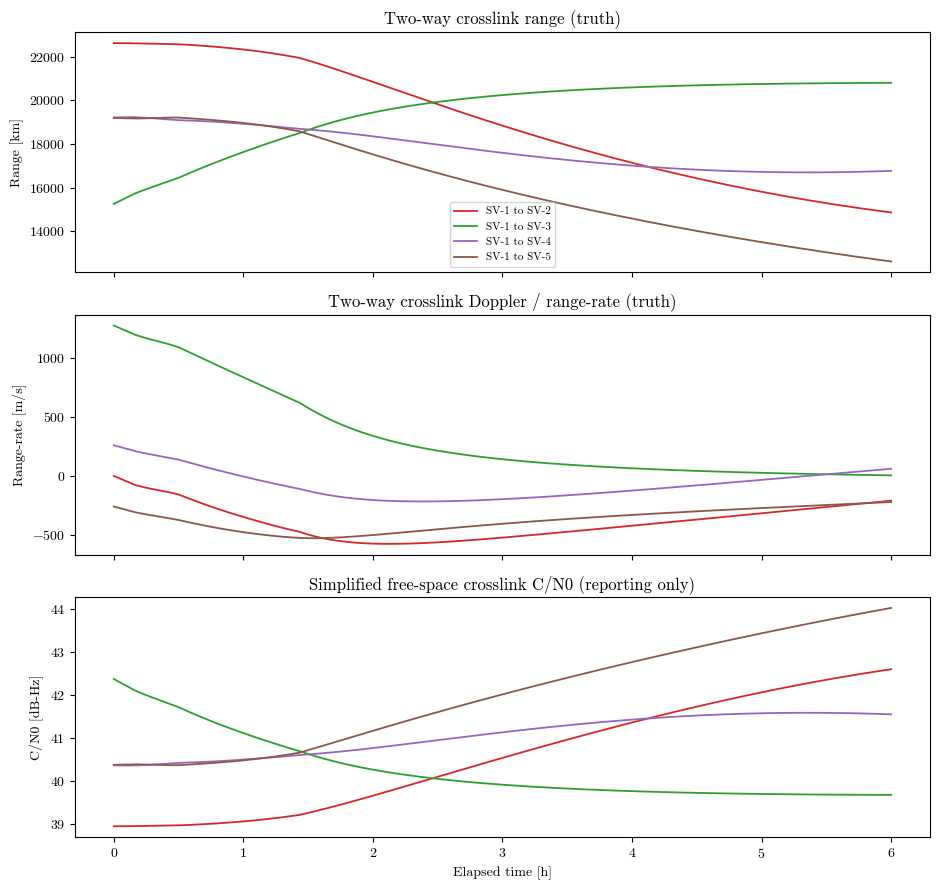

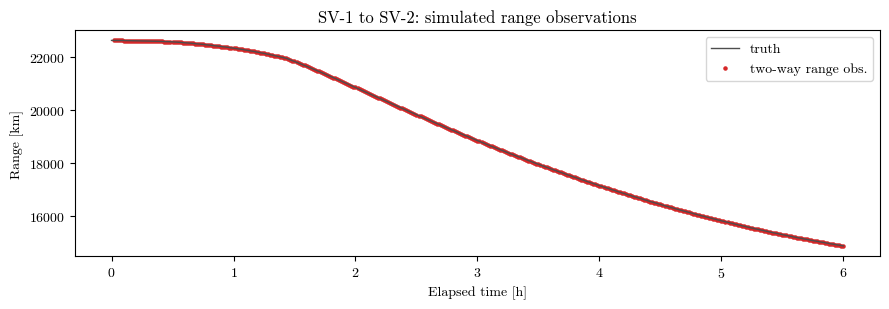

In [6]:
n_links = n_sat - 1
link_names = sat_names[1:]  # SV-1-referenced crosslinks (columns of range_true_m)
link_colors = sat_colors[1:]

fig, axes = plt.subplots(3, 1, figsize=(9.5, 9), sharex=True)

for i in range(n_links):
    color = link_colors[i]
    label = f"{sat_names[0]} to {link_names[i]}"
    axes[0].plot(t_h, res.range_true_m[:, i] / 1e3, color=color, lw=1.3, label=label)
    axes[1].plot(t_h, res.range_rate_true_mps[:, i], color=color, lw=1.3, label=label)
    axes[2].plot(t_h, res.cn0_dbhz[:, i], color=color, lw=1.3, label=label)

axes[0].set_ylabel("Range [km]")
axes[0].set_title("Two-way crosslink range (truth)")
axes[0].legend(loc="best", fontsize=8)

axes[1].set_ylabel("Range-rate [m/s]")
axes[1].set_title("Two-way crosslink Doppler / range-rate (truth)")

axes[2].set_ylabel("C/N0 [dB-Hz]")
axes[2].set_xlabel("Elapsed time [h]")
axes[2].set_title("Simplified free-space crosslink C/N0 (reporting only)")

plt.tight_layout()
plt.show()

# Zoom on one link to show the simulated noisy observations against truth
i_demo = 0
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(t_h, res.range_true_m[:, i_demo] / 1e3, color="0.3", lw=1, label="truth")
ax.scatter(
    t_h,
    res.range_obs_m[:, i_demo] / 1e3,
    s=5,
    color=link_colors[i_demo],
    label="two-way range obs.",
)
ax.set_ylabel("Range [km]")
ax.set_xlabel("Elapsed time [h]")
ax.set_title(f"{sat_names[0]} to {link_names[i_demo]}: simulated range observations")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

## 5. Distributed ODTS convergence -- all five filters

Each satellite's own filter is compared against the truth and its formal 3-sigma
covariance envelope. The top row shows every satellite's own position and clock-bias
error under the full system. The bottom row isolates the two observability
contributions across the constellation mean:

- **Orbit** comes from the crosslinks *and the inter-agent exchange*. Two-way ranging
  only fixes geometry relative to neighbors whose states are known; sharing each
  filter's converged self-estimate every 10 minutes is what turns coarse neighbor
  priors into tight ones, so the position error collapses (compare *no-exchange*).
- **Timing** comes from the surface station. Two-way crosslinks cancel clock bias to
  first order, so without the station the clocks drift essentially unobserved (compare
  *no-station*); the rotating one-way pseudorange pins them down.

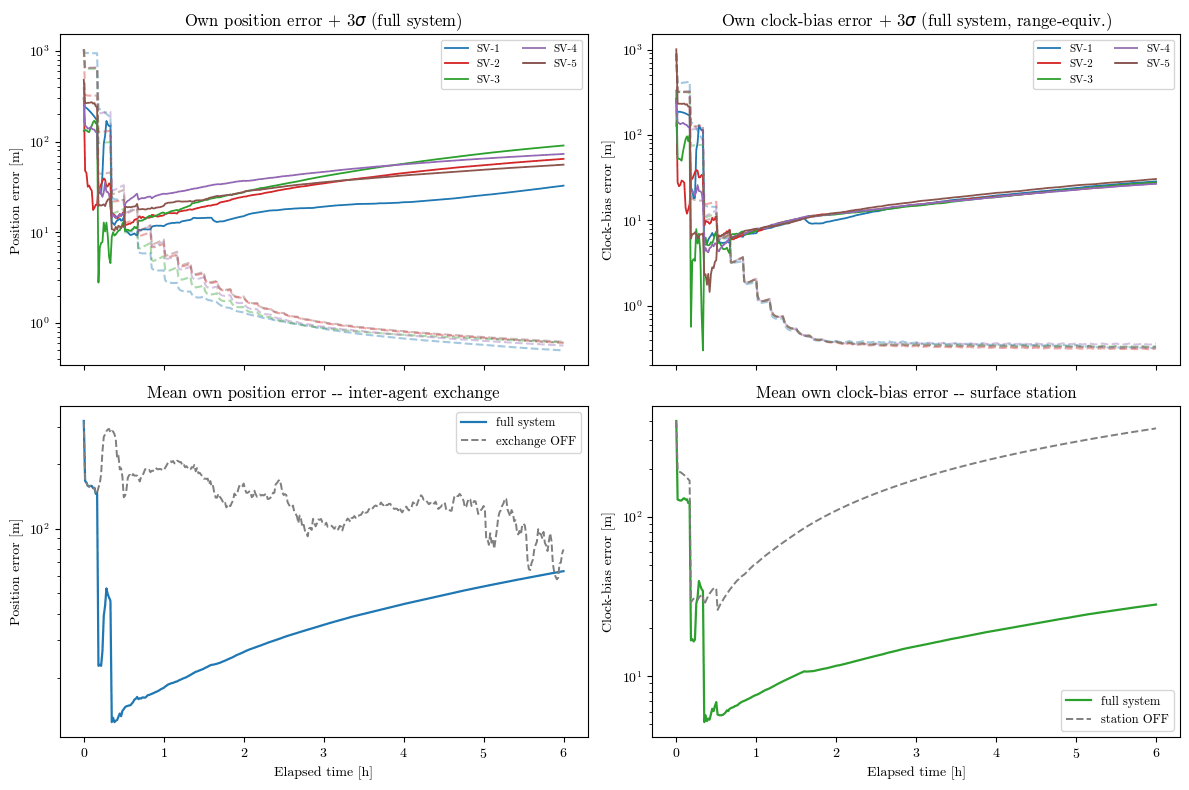

Final constellation-mean own error:
  position : full    63.3 m   |  exchange OFF     79.9 m
  clock    : full   28.11 m   |  station  OFF   357.08 m


In [7]:
def pos_err_ts(r, j):
    return np.linalg.norm(r.truth_states[j][:, :3] - own_block(r, j)[:, :3], axis=1)


def pos_3sig(r, j):
    cd, off = r.cov_diag[j], 8 * j
    return 3 * np.sqrt(cd[:, off] + cd[:, off + 1] + cd[:, off + 2])


def clk_err_ts(r, j):
    return np.abs(r.truth_states[j][:, 6] - own_block(r, j)[:, 6]) * C_MPS


def clk_3sig(r, j):
    return 3 * np.sqrt(r.cov_diag[j][:, 8 * j + 6]) * C_MPS


mean_pos = lambda r: np.mean([pos_err_ts(r, j) for j in range(n_sat)], axis=0)
mean_clk = lambda r: np.mean([clk_err_ts(r, j) for j in range(n_sat)], axis=0)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

# (0,0) per-satellite own position error + 3-sigma (full system)
for j in range(n_sat):
    axes[0, 0].plot(
        t_h, pos_err_ts(res, j), color=sat_colors[j], lw=1.3, label=sat_names[j]
    )
    axes[0, 0].plot(t_h, pos_3sig(res, j), "--", color=sat_colors[j], alpha=0.4)
axes[0, 0].set_yscale("log")
axes[0, 0].set_title("Own position error + 3$\\sigma$ (full system)")
axes[0, 0].set_ylabel("Position error [m]")
axes[0, 0].legend(loc="best", fontsize=8, ncol=2)

# (0,1) per-satellite own clock-bias error + 3-sigma (full system)
for j in range(n_sat):
    axes[0, 1].plot(
        t_h, clk_err_ts(res, j), color=sat_colors[j], lw=1.3, label=sat_names[j]
    )
    axes[0, 1].plot(t_h, clk_3sig(res, j), "--", color=sat_colors[j], alpha=0.4)
axes[0, 1].set_yscale("log")
axes[0, 1].set_title("Own clock-bias error + 3$\\sigma$ (full system, range-equiv.)")
axes[0, 1].set_ylabel("Clock-bias error [m]")
axes[0, 1].legend(loc="best", fontsize=8, ncol=2)

# (1,0) constellation-mean position: exchange drives the orbit
axes[1, 0].plot(t_h, mean_pos(res), color="#1F77B4", lw=1.6, label="full system")
axes[1, 0].plot(
    t_h, mean_pos(res_noex), color="#7F7F7F", lw=1.4, ls="--", label="exchange OFF"
)
axes[1, 0].set_yscale("log")
axes[1, 0].set_title("Mean own position error -- inter-agent exchange")
axes[1, 0].set_ylabel("Position error [m]")
axes[1, 0].set_xlabel("Elapsed time [h]")
axes[1, 0].legend(loc="best", fontsize=9)

# (1,1) constellation-mean clock: station drives the timing
axes[1, 1].plot(t_h, mean_clk(res), color="#2CA02C", lw=1.6, label="full system")
axes[1, 1].plot(
    t_h, mean_clk(res_nost), color="#7F7F7F", lw=1.4, ls="--", label="station OFF"
)
axes[1, 1].set_yscale("log")
axes[1, 1].set_title("Mean own clock-bias error -- surface station")
axes[1, 1].set_ylabel("Clock-bias error [m]")
axes[1, 1].set_xlabel("Elapsed time [h]")
axes[1, 1].legend(loc="best", fontsize=9)

plt.tight_layout()
plt.show()

print("Final constellation-mean own error:")
print(
    f"  position : full {mean_pos(res)[-1]:7.1f} m   |  exchange OFF {mean_pos(res_noex)[-1]:8.1f} m"
)
print(
    f"  clock    : full {mean_clk(res)[-1]:7.2f} m   |  station  OFF {mean_clk(res_nost)[-1]:8.2f} m"
)

## 6. Surface-station beacon coverage and pseudorange residuals

Each station is a **beacon**: every epoch it exchanges a one-way pseudorange (and its
Doppler) with every satellite above its elevation mask. The top panel shows how many of
the three stations see each satellite over time -- the coverage the onboard filters get
for absolute timing and the centralized ground filter (Section 10) gets for everything.
The low-perilune `SV-1` dips below the stations' horizons for long stretches, so it is
covered least -- which is exactly why it is the hardest satellite for the ground filter.
The bottom panel shows each satellite's onboard pre-fit station pseudorange residual,
which should sit within the measurement noise once the filters have converged.

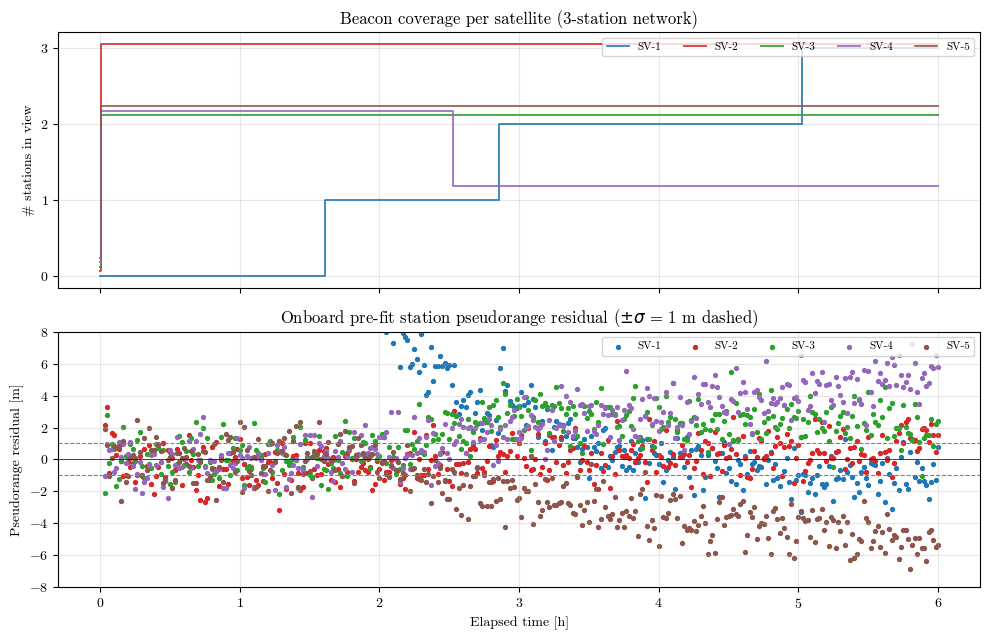

Fraction of epochs each satellite is seen by >=1 station:
  SV-1:  73.1%   (mean 1.42 stations in view)
  SV-2:  99.7%   (mean 2.99 stations in view)
  SV-3:  99.7%   (mean 1.99 stations in view)
  SV-4:  99.7%   (mean 1.42 stations in view)
  SV-5:  99.7%   (mean 1.99 stations in view)

Station pseudorange pre-fit RMS: 36.6 m (noise sigma = 1 m)


In [8]:
visible = np.asarray(res.station_visible)  # [N x n_sat] # stations seeing each sat
resid = np.asarray(res.station_pr_resid_m)  # [N x n_sat] onboard pre-fit residuals

fig, axes = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True)

# Beacon coverage: # of stations in view of each satellite (stacked step lines).
for j in range(n_sat):
    axes[0].plot(t_h, visible[:, j] + 0.06 * j, color=sat_colors[j], lw=1.2,
                 drawstyle="steps-mid", label=sat_names[j])
axes[0].set_yticks(range(len(res.station_pos_mci) + 1))
axes[0].set_ylabel("# stations in view")
axes[0].set_title(f"Beacon coverage per satellite ({len(res.station_pos_mci)}-station network)")
axes[0].legend(loc="upper right", fontsize=8, ncol=5)
axes[0].grid(True, alpha=0.3)

# Onboard pre-fit station pseudorange residual per satellite (NaN where not covered).
for j in range(n_sat):
    m = np.isfinite(resid[:, j])
    axes[1].scatter(t_h[m], resid[m, j], s=8, color=sat_colors[j], label=sat_names[j])
sig = cfg.surface_stations[0].pseudorange_sigma_m
axes[1].axhline(0.0, color="k", lw=0.5)
for sgn in (1, -1):
    axes[1].axhline(sgn * sig, color="0.5", lw=0.8, ls="--")
axes[1].set_ylim(-8 * sig, 8 * sig)
axes[1].set_ylabel("Pseudorange residual [m]")
axes[1].set_xlabel("Elapsed time [h]")
axes[1].set_title(f"Onboard pre-fit station pseudorange residual ($\\pm\\sigma$ = {sig:.0f} m dashed)")
axes[1].legend(loc="upper right", fontsize=8, ncol=5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

cov_frac = (visible > 0).mean(axis=0) * 100
print("Fraction of epochs each satellite is seen by >=1 station:")
for j in range(n_sat):
    print(f"  {sat_names[j]}: {cov_frac[j]:5.1f}%   (mean {visible[:, j].mean():.2f} stations in view)")
rms = np.sqrt(np.nanmean(resid[np.isfinite(resid)] ** 2))
print(f"\nStation pseudorange pre-fit RMS: {rms:.1f} m (noise sigma = {sig:.0f} m)")

## 7. Consider-state exchange between the parallel filters

Each satellite carries the others as consider states. Between exchanges a consider
block only grows -- it is propagated with process noise and never corrected by that
satellite's own measurements. Every 10 minutes, though, the inter-agent exchange
refreshes it from the neighbor's freshly converged self-estimate (mean **and**
covariance), producing the characteristic **sawtooth**: grow, reset, grow, reset.

Below, one filter's (`SV-1`'s) knowledge of each other satellite is shown. The dashed
line is the same quantity with the exchange disabled: it grows without bound from the
coarse 500 m broadcast prior, which is exactly the neighbor uncertainty that would
otherwise cap the whole constellation's accuracy.

> **This is the naive-overwrite baseline** (`exchange_use_covariance_intersection =
> False`): each reset simply *adopts* the neighbor's self-reported covariance. That
> makes the sawtooth reset to a very small value -- but as the next section shows, that
> small value is not trustworthy, because the two filters being fused are correlated.
> Section 8 quantifies the resulting over-confidence and fixes it.

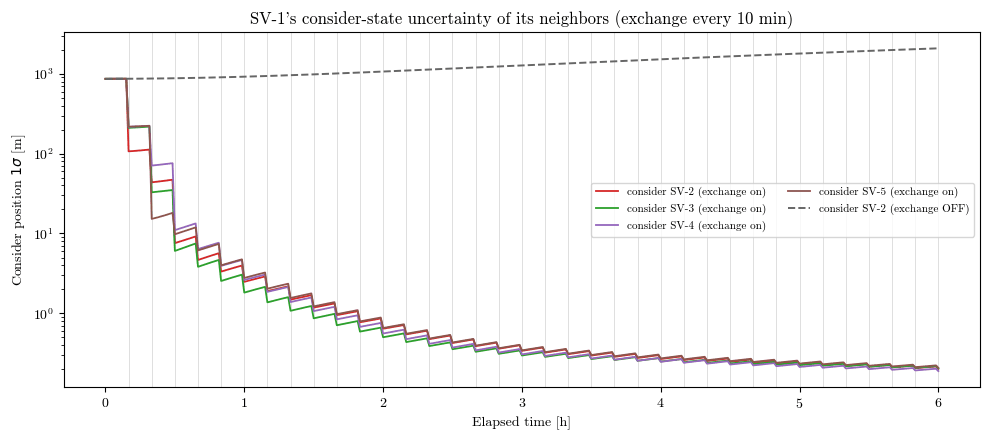

SV-1's consider-SV-2 position 1-sigma at the final epoch: 0.2 m (exchange on) vs 2086.4 m (exchange off)


In [9]:
def consider_pos_sigma(r, filt, g):
    """1-sigma position uncertainty of filter `filt`'s consider block for satellite g."""
    cd, off = r.cov_diag[filt], 8 * g
    return np.sqrt(cd[:, off] + cd[:, off + 1] + cd[:, off + 2])


filt = 0  # inspect SV-1's filter
neighbors = [g for g in range(n_sat) if g != filt]

fig, ax = plt.subplots(figsize=(10, 4.5))
for g in neighbors:
    ax.plot(
        t_h,
        consider_pos_sigma(res, filt, g),
        color=sat_colors[g],
        lw=1.3,
        label=f"consider {sat_names[g]} (exchange on)",
    )
# One neighbor with the exchange disabled, for contrast.
g0 = neighbors[0]
ax.plot(
    t_h,
    consider_pos_sigma(res_noex, filt, g0),
    color="0.4",
    lw=1.4,
    ls="--",
    label=f"consider {sat_names[g0]} (exchange OFF)",
)

# Mark the 10-minute exchange epochs.
for te in np.arange(
    cfg.consider_exchange_interval_s,
    cfg.duration_s + 1,
    cfg.consider_exchange_interval_s,
):
    ax.axvline(te / 3600.0, color="0.85", lw=0.6, zorder=0)

ax.set_yscale("log")
ax.set_ylabel(r"Consider position $1\sigma$ [m]")
ax.set_xlabel("Elapsed time [h]")
ax.set_title(
    f"{sat_names[filt]}'s consider-state uncertainty of its neighbors "
    f"(exchange every {cfg.consider_exchange_interval_s / 60:.0f} min)"
)
ax.legend(loc="best", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

print(
    f"{sat_names[filt]}'s consider-{sat_names[g0]} position 1-sigma at the final epoch: "
    f"{consider_pos_sigma(res, filt, g0)[-1]:.1f} m (exchange on) vs "
    f"{consider_pos_sigma(res_noex, filt, g0)[-1]:.1f} m (exchange off)"
)

## 8. Is the covariance honest? Consistency and Covariance Intersection

Sections 5-7 tracked *accuracy* (error vs. its formal 3-$\sigma$ envelope). But a
navigation filter also has to report **trustworthy uncertainty** -- a consumer of the
ephemeris (a lander, a rover, an integrity monitor) trusts the covariance, not the
(unknowable) true error. The standard consistency check is **NEES** (Normalized
Estimation Error Squared):

$$\varepsilon_k = (\hat{x}_k - x_k)^\top P_k^{-1} (\hat{x}_k - x_k), \qquad
  \mathbb{E}[\varepsilon_k] = \dim(x)$$

For a *consistent* filter the NEES sits near its number of degrees of freedom (3 for
position, 8 for the full state). $\varepsilon_k \gg \dim$ means $P_k$ is **optimistic**:
the filter claims far more accuracy than it has.

**Why the naive exchange is optimistic.** The five filters are *not* independent -- they
share the same two-way crosslink observations, and every 10-minute exchange has already
mixed their estimates. Overwriting a consider block with a neighbor's posterior (and
zeroing its cross-covariance) treats that broadcast as *fresh, independent* information.
It is not, so the same information gets counted again and again: a **data-incest**
feedback loop. Each filter's consider blocks collapse $\Rightarrow$ the crosslink
innovation covariance $S = R + HPH^\top$ barely inflates $\Rightarrow$ the own covariance
collapses $\Rightarrow$ that over-confident estimate is broadcast $\Rightarrow$ neighbors
collapse further. The reported $\sigma$ ends up *orders of magnitude* below the true error.

**The consistent fix: Covariance Intersection (Julier & Uhlmann).** Fuse each broadcast
into the consider block as a **convex** combination of information,

$$P_b' = \big(w\,P_b^{-1} + (1-w)\,P_{\text{bcast}}^{-1}\big)^{-1}, \qquad
  m_b' = P_b'\big(w\,P_b^{-1} m_b + (1-w)\,P_{\text{bcast}}^{-1} m_{\text{bcast}}\big).$$

Because it is convex (weights sum to 1) rather than additive, CI is **guaranteed
consistent for *any* unknown cross-correlation** between the two estimates and cannot
manufacture confidence -- exactly what breaks the incest loop. It addresses both the
exchange-induced and shared-measurement optimism at once. Enable it with
`cfg.exchange_use_covariance_intersection = True` (and `exchange_ci_weight` to pin $w$,
else it is chosen per block by minimizing the fused-block covariance).

**One caveat -- CI and process noise compose.** CI keeps the *fusion* consistent only if
each filter's own posterior is *itself* consistent. Here the absolute position is weakly
observable (a single round-robin station), so each own covariance is also too tight until
the process noise `process_accel_sigma_mps2` is raised to cover that unmodelled drift.
The two levers are complementary: process noise makes each broadcast honest, CI keeps the
fusion of those honest broadcasts honest. Below we turn on **both** and re-check the NEES.

[23.03] ISL ODTS 100%|██████████| 360/360 [00:05<00:00, 62.9 it/s]


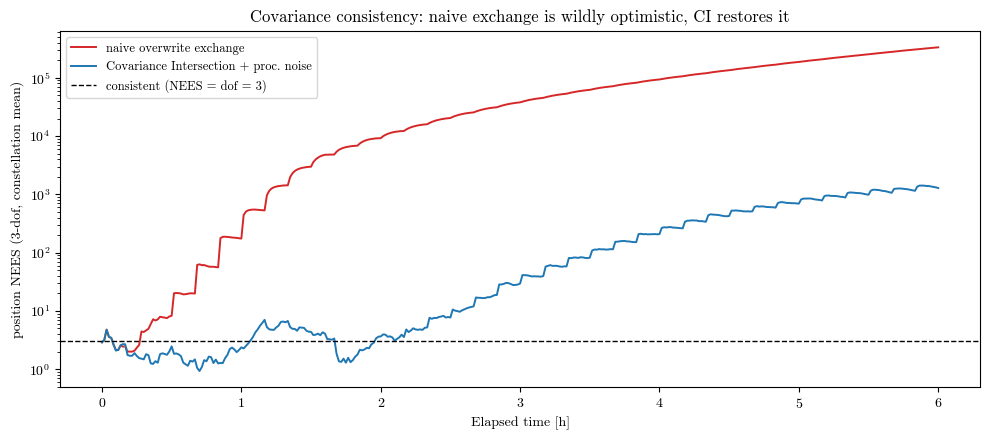

                   pos NEES(3)  pos RMSE [m]  reported sig [m]
naive overwrite        97257.0          44.0              0.41
CI + proc. noise         339.7          21.5             15.81

The naive filter looks a little more accurate but reports a sigma tens of times
below its true error -- its position NEES is ~32,419x the consistent
value of 3. Covariance Intersection + process noise cuts the over-confidence by
~286x (NEES ~340, i.e. a ~10.6x sigma
factor), trading a little accuracy for a covariance the same order as the true error.


In [10]:
# --- NEES helpers -------------------------------------------------------------------
def own_cov_full(r, j):
    """Filter j's own 8x8 covariance time series, shape [N, 8, 8]."""
    return np.asarray(r.cov_own_full[j]).reshape(len(r.t_s), 8, 8)


def nees_ts(r, dof=3):
    """Per-epoch NEES averaged over the constellation.

    dof=3 -> position only, dof=8 -> full [r, v, clock_bias, clock_drift] state.
    A consistent filter sits near `dof`; NEES >> dof means the covariance is optimistic.
    """
    N, ns = len(r.t_s), len(r.satellite_names)
    out = np.full(N, np.nan)
    for k in range(N):
        vals = []
        for j in range(ns):
            e = own_block(r, j)[k, :dof] - r.truth_states[j][k, :dof]
            P = own_cov_full(r, j)[k, :dof, :dof]
            vals.append(float(e @ np.linalg.solve(P, e)))
        out[k] = np.mean(vals)
    return out


# --- Consistent variant: Covariance Intersection exchange + matched process noise ----
# `res_ci` is the `ci` variant produced by ex8_run_isl_odts.py (loaded in the setup cell):
# the SAME truth/geometry, but the consider-state exchange uses Covariance Intersection
# (ci_weight 0.95) with a larger process noise to cover the weakly-observable drift.

DOF = 3  # position-only NEES
nees_naive = nees_ts(res, DOF)
nees_ci = nees_ts(res_ci, DOF)
settle = t_h > 1.0  # ignore the initial transient in the summary statistics


def rms_pos(r):
    return np.sqrt(
        np.mean([pos_err_ts(r, j)[settle] ** 2 for j in range(n_sat)])
    )


def mean_pos_sigma(r):
    s = [np.sqrt(np.trace(own_cov_full(r, j)[k, :3, :3])) for j in range(n_sat)
         for k in np.where(settle)[0]]
    return np.mean(s)


fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(t_h, nees_naive, color="#D62728", lw=1.4, label="naive overwrite exchange")
ax.plot(t_h, nees_ci, color="#1F77B4", lw=1.4, label="Covariance Intersection + proc. noise")
ax.axhline(DOF, color="k", lw=1.0, ls="--", label=f"consistent (NEES = dof = {DOF})")
ax.set_yscale("log")
ax.set_ylabel(f"position NEES ({DOF}-dof, constellation mean)")
ax.set_xlabel("Elapsed time [h]")
ax.set_title("Covariance consistency: naive exchange is wildly optimistic, CI restores it")
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()

print(f"{'':16}{'pos NEES(3)':>14}{'pos RMSE [m]':>14}{'reported sig [m]':>18}")
stats_out = {}
for tag, r in [("naive overwrite", res), ("CI + proc. noise", res_ci)]:
    n = np.nanmean(nees_ts(r, DOF)[settle])
    stats_out[tag] = (n, rms_pos(r), mean_pos_sigma(r))
    print(f"{tag:16}{n:14.1f}{stats_out[tag][1]:14.1f}{stats_out[tag][2]:18.2f}")

n_naive = stats_out["naive overwrite"][0]
n_ci = stats_out["CI + proc. noise"][0]
print(
    f"\nThe naive filter looks a little more accurate but reports a sigma tens of times\n"
    f"below its true error -- its position NEES is ~{n_naive / DOF:,.0f}x the consistent\n"
    f"value of {DOF}. Covariance Intersection + process noise cuts the over-confidence by\n"
    f"~{n_naive / n_ci:,.0f}x (NEES ~{n_ci:.0f}, i.e. a ~{np.sqrt(n_ci / DOF):.1f}x sigma\n"
    f"factor), trading a little accuracy for a covariance the same order as the true error."
)

## 9. Two-way time and frequency transfer on the crosslinks

The dedicated satellite-to-satellite link is more than a ranging channel. Coherent
two-way ranging **cancels** the clocks (its sum-of-one-ways gives geometric range), so by
itself it says nothing about how the satellites' clocks relate. Two extra observables
close that gap, at a cost comparable to the ranging itself:

- **Two-way time transfer** — the *difference* of the two one-way exchanges recovers the
  clock-bias offset $C\,(b_i - b_j)$ between the endpoints.
- **Two-way frequency transfer** — its rate companion, $C\,(d_i - d_j)$, recovers the
  clock-*drift* difference directly (rather than waiting for it to integrate into bias).

Together they make the whole constellation's **relative** clocks and drifts observable
across the crosslink mesh; the surface-station beacons then only have to pin the one
**absolute** time reference. Below we turn the two transfers on in sequence (using the
consistent Covariance-Intersection exchange from Section 8) and watch the constellation
clock-bias and clock-drift errors drop.


[29.15] ISL ODTS 100%|██████████| 360/360 [00:05<00:00, 66.2 it/s]

[34.61] ISL ODTS 100%|██████████| 360/360 [00:06<00:00, 53.7 it/s]



[41.34] ISL ODTS 100%|██████████| 360/360 [00:05<00:00, 65.3 it/s]


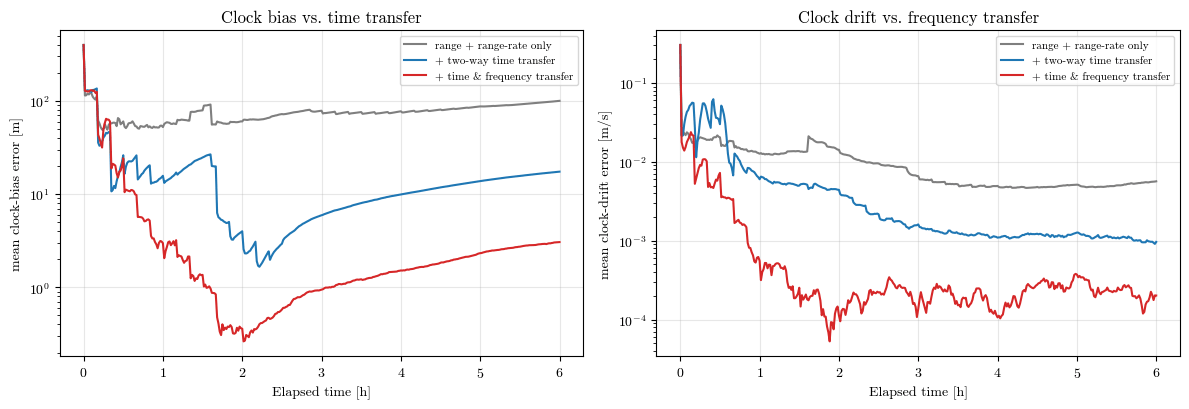

crosslink observables             clk bias [m]  clk drift [m/s]
range + range-rate only                  100.0          0.00567
+ two-way time transfer                   17.4          0.00097
+ time & frequency transfer                3.1          0.00020

Two-way ranging alone leaves the clocks weakly tied; adding time transfer collapses
the clock-bias error, and frequency transfer additionally tightens the clock drift.


In [11]:
# Turn the two crosslink clock observables on in sequence, on the SAME truth/geometry.
# Use the consistent CI exchange (Section 8) so the comparison is not muddied by the
# naive-overwrite data incest.
transfer_variants = [
    ("range + range-rate only", False, False, "#7F7F7F"),
    ("+ two-way time transfer", True, False, "#1F77B4"),
    ("+ time & frequency transfer", True, True, "#D62728"),
]


def clk_err_ts_mean(r):
    return np.mean([np.abs(r.truth_states[j][:, 6] - own_block(r, j)[:, 6]) * C_MPS
                    for j in range(n_sat)], axis=0)


def drift_err_ts_mean(r):
    return np.mean([np.abs(r.truth_states[j][:, 7] - own_block(r, j)[:, 7]) * C_MPS
                    for j in range(n_sat)], axis=0)


# The three sweep variants (CI exchange, weight 0.9) are produced by ex8_run_isl_odts.py
# and loaded here from their .npz, in the same label order as `transfer_variants`.
_tf_tags = ["tf_rr", "tf_tt", "tf_ttft"]
runs_tf = {label: _Res(_data_dir / f"results_{tag}.npz", _meta["satellite_names"])
           for (label, _tt, _ft, _c), tag in zip(transfer_variants, _tf_tags)}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for label, tt, ft, color in transfer_variants:
    r = runs_tf[label]
    axes[0].plot(t_h, clk_err_ts_mean(r), color=color, lw=1.5, label=label)
    axes[1].plot(t_h, drift_err_ts_mean(r), color=color, lw=1.5, label=label)
axes[0].set_yscale("log"); axes[0].set_ylabel("mean clock-bias error [m]")
axes[0].set_xlabel("Elapsed time [h]"); axes[0].set_title("Clock bias vs. time transfer")
axes[0].legend(loc="best", fontsize=8); axes[0].grid(True, alpha=0.3)
axes[1].set_yscale("log"); axes[1].set_ylabel("mean clock-drift error [m/s]")
axes[1].set_xlabel("Elapsed time [h]"); axes[1].set_title("Clock drift vs. frequency transfer")
axes[1].legend(loc="best", fontsize=8); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"{'crosslink observables':32}{'clk bias [m]':>14}{'clk drift [m/s]':>17}")
for label, tt, ft, _ in transfer_variants:
    r = runs_tf[label]
    print(f"{label:32}{clk_err_ts_mean(r)[-1]:14.1f}{drift_err_ts_mean(r)[-1]:17.5f}")
print(
    "\nTwo-way ranging alone leaves the clocks weakly tied; adding time transfer collapses\n"
    "the clock-bias error, and frequency transfer additionally tightens the clock drift."
)

## 10. Centralized ground filter vs. the distributed ISL scheme

So far every satellite has run its **own** onboard filter, fusing crosslinks with a little
station aiding. The classic alternative is a **centralized** ground filter: a single EKF,
hosted at the ground segment, that estimates *every* satellite's orbit and clock from the
surface-station one-way pseudorange + Doppler **alone** — no inter-satellite measurements
are downlinked. the `IslOdtsCoordinatorApp` runs this filter alongside the distributed ones
(`enable_centralized_ground_filter`), so we can compare them head-to-head on identical
truth and station geometry.

The contrast is the point of the example. Because it has no crosslinks, the ground filter
sees each satellite only through the narrow cone of ground stations that happen to be in
view — range-only tracking that is weakly observable in cross-range and, for the
low-perilune `SV-1` (which spends long stretches below every station's horizon), barely
observable at all. The distributed ISL scheme, by contrast, ties every satellite to four
neighbors continuously and uses the ground station only for the one absolute time
reference — so it delivers **uniform** accuracy across the whole constellation, including
the satellite the ground network struggles with most.

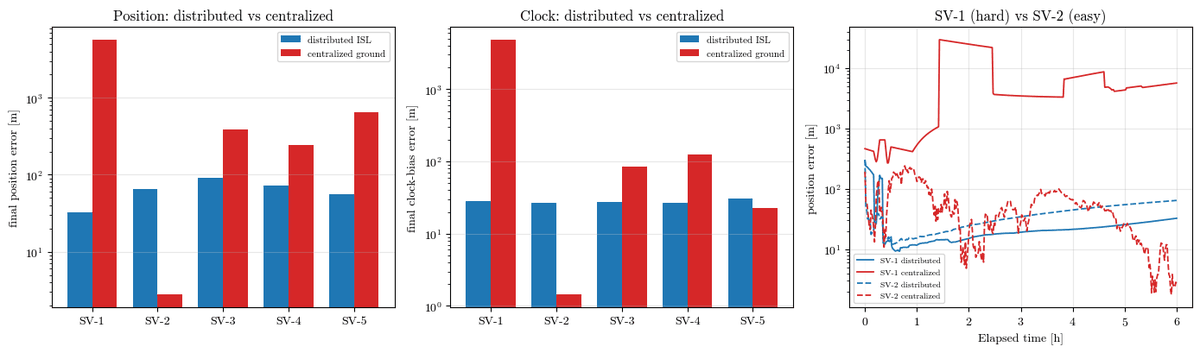

   sat  ISL pos [m] ground pos [m]  ISL clk [m] ground clk [m]
  SV-1         32.7         5681.2         28.5         4852.0
  SV-2         64.5            2.8         27.0            1.4
  SV-3         90.4          387.5         27.8           86.0
  SV-4         73.1          244.4         26.8          124.5
  SV-5         55.6          651.7         30.4           22.8

The distributed ISL filter is uniform across the constellation (33-90 m). The centralized ground filter does well on
well-covered satellites but is far worse on the poorly-observed low-perilune SV-1 -- the observability that crosslinks provide, and a ground network alone cannot.


In [12]:
# The centralized filter ran inside `res` (est_central: [N x 8*n_sat], global sat order).
est_c = np.asarray(res.est_central)


def dist_pos_err_ts(r, j):
    return np.linalg.norm(r.truth_states[j][:, :3] - own_block(r, j)[:, :3], axis=1)


def cen_pos_err_ts(r, j):
    return np.linalg.norm(r.truth_states[j][:, :3] - est_c[:, 8 * j : 8 * j + 3], axis=1)


def cen_clk_err(j):
    return abs(res.truth_states[j][-1, 6] - est_c[-1, 8 * j + 6]) * C_MPS


dist_pos = [final_pos_err(res, j) for j in range(n_sat)]
cen_pos = [np.linalg.norm(res.truth_states[j][-1, :3] - est_c[-1, 8 * j : 8 * j + 3])
           for j in range(n_sat)]
dist_clk = [final_clk_err_m(res, j) for j in range(n_sat)]
cen_clk = [cen_clk_err(j) for j in range(n_sat)]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
x = np.arange(n_sat)
w = 0.38

# (a) final position error per satellite: distributed vs centralized
axes[0].bar(x - w / 2, dist_pos, w, color="#1F77B4", label="distributed ISL")
axes[0].bar(x + w / 2, cen_pos, w, color="#D62728", label="centralized ground")
axes[0].set_yscale("log"); axes[0].set_xticks(x); axes[0].set_xticklabels(sat_names)
axes[0].set_ylabel("final position error [m]")
axes[0].set_title("Position: distributed vs centralized")
axes[0].legend(loc="best", fontsize=8); axes[0].grid(True, axis="y", alpha=0.3)

# (b) final clock-bias error per satellite
axes[1].bar(x - w / 2, dist_clk, w, color="#1F77B4", label="distributed ISL")
axes[1].bar(x + w / 2, cen_clk, w, color="#D62728", label="centralized ground")
axes[1].set_yscale("log"); axes[1].set_xticks(x); axes[1].set_xticklabels(sat_names)
axes[1].set_ylabel("final clock-bias error [m]")
axes[1].set_title("Clock: distributed vs centralized")
axes[1].legend(loc="best", fontsize=8); axes[1].grid(True, axis="y", alpha=0.3)

# (c) position-error time series for the hardest (SV-1) and an easy (SV-2) satellite
for j, ls in [(0, "-"), (1, "--")]:
    axes[2].plot(t_h, dist_pos_err_ts(res, j), color="#1F77B4", ls=ls, lw=1.3,
                 label=f"{sat_names[j]} distributed")
    axes[2].plot(t_h, cen_pos_err_ts(res, j), color="#D62728", ls=ls, lw=1.3,
                 label=f"{sat_names[j]} centralized")
axes[2].set_yscale("log"); axes[2].set_xlabel("Elapsed time [h]")
axes[2].set_ylabel("position error [m]")
axes[2].set_title("SV-1 (hard) vs SV-2 (easy)")
axes[2].legend(loc="best", fontsize=7); axes[2].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"{'sat':>6}{'ISL pos [m]':>13}{'ground pos [m]':>15}{'ISL clk [m]':>13}{'ground clk [m]':>15}")
for j in range(n_sat):
    print(f"{sat_names[j]:>6}{dist_pos[j]:13.1f}{cen_pos[j]:15.1f}{dist_clk[j]:13.1f}{cen_clk[j]:15.1f}")
print(
    f"\nThe distributed ISL filter is uniform across the constellation "
    f"({min(dist_pos):.0f}-{max(dist_pos):.0f} m). The centralized ground filter does well on\n"
    f"well-covered satellites but is far worse on the poorly-observed low-perilune {sat_names[0]} "
    f"-- the observability that crosslinks provide, and a ground network alone cannot."
)